In [14]:
%pip install openneuro-py mne scikit-learn pandas matplotlib seaborn


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [15]:
#Feature vector: 128 channels × 5 bands = 640 features per session

import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import welch
from pathlib import Path

mne.set_log_level('WARNING')
%matplotlib inline

DATA_DIR = Path('../data/raw')
PROC_DIR  = Path('../data/processed')
OUT_DIR   = Path('../outputs')

SUBJECTS = ['001', '002', '003', '004', '005']
SESSIONS = list(range(1, 13))

GENRE_MAP = {
    1:'Deep House', 2:'Indie', 3:'Electronics', 4:'New Age',
    5:'Electronic Dance', 6:'Ambient', 7:'Hindustani Classical',
    8:'Indian Semi-Classical', 9:'Indian Folk', 10:'Soft Jazz',
    11:'Goth Rock', 12:'Progressive Instrumental Rock'
}

BANDS = {
    'delta': (1,  4),
    'theta': (4,  8),
    'alpha': (8,  13),
    'beta':  (13, 30),
    'gamma': (30, 40),
}

print('Setup complete.')
print(f'Features per session: 128 x {len(BANDS)} = {128*len(BANDS)}')

Setup complete.
Features per session: 128 x 5 = 640


In [16]:
##  Band Power Function

def extract_band_powers(data, sfreq, bands):
    freqs, psd = welch(data, fs=sfreq, nperseg=int(sfreq * 2))

    features   = []
    feat_names = []
    for ch_idx in range(data.shape[0]):
        for band_name, (lo, hi) in bands.items():
            idx        = np.logical_and(freqs >= lo, freqs <= hi)
            # np.trapz renamed to np.trapezoid in newer numpy
            try:
                band_power = np.trapezoid(psd[ch_idx, idx], freqs[idx])
            except AttributeError:
                band_power = np.trapz(psd[ch_idx, idx], freqs[idx])
            features.append(band_power)
            feat_names.append(f'ch{ch_idx:03d}_{band_name}')

    return np.array(features), feat_names

print('extract_band_powers() ready.')

extract_band_powers() ready.


In [17]:
## Test on One Session

fif_file = PROC_DIR / 'sub-001_ses-01_clean.fif'
raw      = mne.io.read_raw_fif(fif_file, preload=True, verbose=False)
data     = raw.get_data()
sfreq    = raw.info['sfreq']
del raw

features, feat_names = extract_band_powers(data, sfreq, BANDS)
del data

print(f'Feature vector : {features.shape}')
print(f'Sample names   : {feat_names[:5]}')
print(f'Sample values  : {features[:5].round(8)}')

Feature vector : (645,)
Sample names   : ['ch000_delta', 'ch000_theta', 'ch000_alpha', 'ch000_beta', 'ch000_gamma']
Sample values  : [0. 0. 0. 0. 0.]


/tmp/ipykernel_12517/2841506232.py:4: RuntimeWarning: This filename (../data/processed/sub-001_ses-01_clean.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw      = mne.io.read_raw_fif(fif_file, preload=True, verbose=False)


In [18]:
## Build Full Feature Matrix (60 sessions)

all_features   = []
all_labels     = []
all_subjects   = []
feat_names_ref = None
errors         = []

for sub in SUBJECTS:
    for ses in SESSIONS:
        fif_file = PROC_DIR / f'sub-{sub}_ses-{ses:02d}_clean.fif'
        genre    = GENRE_MAP[ses]

        if not fif_file.exists():
            print(f'[MISS] sub-{sub} ses-{ses:02d}')
            errors.append((sub, ses))
            continue

        raw   = mne.io.read_raw_fif(fif_file, preload=True, verbose=False)
        data  = raw.get_data()
        sfreq = raw.info['sfreq']
        del raw

        feats, names = extract_band_powers(data, sfreq, BANDS)
        del data

        all_features.append(feats)
        all_labels.append(genre)
        all_subjects.append(sub)
        if feat_names_ref is None:
            feat_names_ref = names

        print(f'[OK] sub-{sub} ses-{ses:02d} ({genre})')

print(f'\nDone: {len(all_features)} sessions, {len(errors)} missing')

/tmp/ipykernel_12517/1821371007.py:19: RuntimeWarning: This filename (../data/processed/sub-001_ses-01_clean.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw   = mne.io.read_raw_fif(fif_file, preload=True, verbose=False)


[OK] sub-001 ses-01 (Deep House)


/tmp/ipykernel_12517/1821371007.py:19: RuntimeWarning: This filename (../data/processed/sub-001_ses-02_clean.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw   = mne.io.read_raw_fif(fif_file, preload=True, verbose=False)


[OK] sub-001 ses-02 (Indie)


/tmp/ipykernel_12517/1821371007.py:19: RuntimeWarning: This filename (../data/processed/sub-001_ses-03_clean.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw   = mne.io.read_raw_fif(fif_file, preload=True, verbose=False)


...

[OK] sub-005 ses-10 (Soft Jazz)


/tmp/ipykernel_12517/1821371007.py:19: RuntimeWarning: This filename (../data/processed/sub-005_ses-11_clean.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw   = mne.io.read_raw_fif(fif_file, preload=True, verbose=False)


[OK] sub-005 ses-11 (Goth Rock)


/tmp/ipykernel_12517/1821371007.py:19: RuntimeWarning: This filename (../data/processed/sub-005_ses-12_clean.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw   = mne.io.read_raw_fif(fif_file, preload=True, verbose=False)


[OK] sub-005 ses-12 (Progressive Instrumental Rock)

Done: 60 sessions, 0 missing


In [19]:
## Save Feature Matrix

X  = np.array(all_features)
df = pd.DataFrame(X, columns=feat_names_ref)
df['label']   = all_labels
df['subject'] = all_subjects

csv_path = OUT_DIR / 'features.csv'
df.to_csv(csv_path, index=False)

print(f'Shape  : {df.shape}  (sessions x features+meta)')
print(f'Saved  : {csv_path}')
print(f'\nLabel distribution:')
print(df['label'].value_counts().to_string())

Shape  : (60, 647)  (sessions x features+meta)
Saved  : ../outputs/features.csv

Label distribution:
label
Deep House                       5
Indie                            5
Electronics                      5
New Age                          5
Electronic Dance                 5
Ambient                          5
Hindustani Classical             5
Indian Semi-Classical            5
Indian Folk                      5
Soft Jazz                        5
Goth Rock                        5
Progressive Instrumental Rock    5


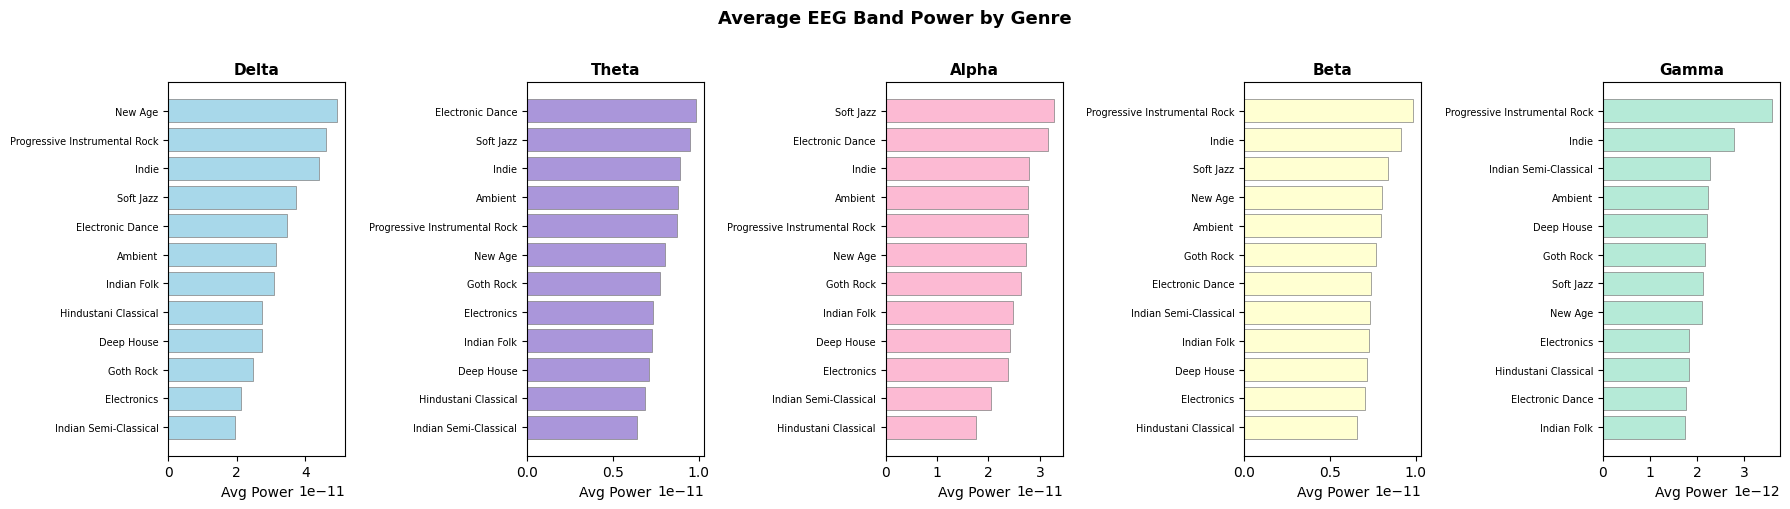

Saved: outputs/03_band_powers_by_genre.png


In [20]:
##  Visualize — Band Powers by Genre

# Average band power per genre (mean across all channels)
band_names = list(BANDS.keys())
summary = {}
for band in band_names:
    cols = [c for c in feat_names_ref if c.endswith(band)]
    summary[band] = df.groupby('label')[cols].mean().mean(axis=1)

summary_df = pd.DataFrame(summary)

fig, axes = plt.subplots(1, 5, figsize=(18, 5), sharey=False)
colors = ['#a8d8ea', '#aa96da', '#fcbad3', '#ffffd2', '#b5ead7']

for ax, band, color in zip(axes, band_names, colors):
    vals = summary_df[band].sort_values()
    ax.barh(vals.index, vals.values, color=color, edgecolor='gray', linewidth=0.5)
    ax.set_title(band.capitalize(), fontweight='bold', fontsize=11)
    ax.set_xlabel('Avg Power')
    ax.tick_params(axis='y', labelsize=7)

plt.suptitle('Average EEG Band Power by Genre', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / '03_band_powers_by_genre.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: outputs/03_band_powers_by_genre.png')

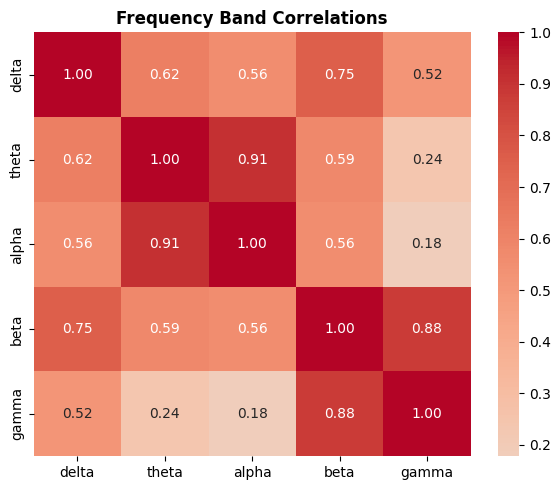

Saved: outputs/03_band_correlation.png


In [21]:
## Visualize — Band Correlation Heatmap

# Are bands correlated with each other?
corr_df = summary_df[band_names].T.corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(summary_df[band_names].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=ax)
ax.set_title('Frequency Band Correlations', fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / '03_band_correlation.png', dpi=120)
plt.show()
print('Saved: outputs/03_band_correlation.png')
